---
title: "Workshop for day 2"
author: "Inspired by Rasmus F Brøndum"
date: "23/05/2025"
format:
  html:
    toc: true
    toc-float: true
---

This document provides the basis for loading the data and training some dynamic classification models using Python libraries like `scikit-learn`, `xgboost`, and `optuna`.

In [1]:
import sys
print(sys.path)

['C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip', 'C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310\\DLLs', 'C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310\\lib', 'C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310', '', 'C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages', 'C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\win32', 'C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\win32\\lib', 'C:\\Users\\jakob\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\Pythonwin']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import multiprocessing

np.random.seed(2025)
cores = multiprocessing.cpu_count()

Load and read the data.

In [3]:
df = pd.read_csv("Data_ready_for_workshop2.csv")

In [4]:
df_cal = df[df['split'] == 'calibration'].copy()
df = df[df['split'] != 'calibration'].copy()

df['split'] = pd.Categorical(df['split'], categories=['train', 'validation', 'test'], ordered=True)

df.sort_values('split', inplace=True)

split_counts = df['split'].value_counts()

# Prepare data
def prepare_data(data):
    X = data.drop(columns=['id', 'date', 'split', 'mevent_nyear'])
    y = LabelEncoder().fit_transform(data['mevent_nyear'])  # ensure 1 is positive class
    return X, y

X, y = prepare_data(df)
X_cal, y_cal = prepare_data(df_cal)
X.reset_index(drop = True)
X_cal.reset_index(drop = True)

,systolic,diastolic,erythrocytes,hemoglobin,wbc,platelets,glucose,potassium,creatine,chol,...,diff_creatine,diff_chol,diff_hdl,diff_ldl,diff_anxiety,diff_sleep,diff_alcohol,diff_fruit,diff_vegetable,diff_cvscore
0,0.352941,0.432990,0.561176,0.839572,0.033987,0.387145,0.114286,0.425532,0.190698,0.368707,...,0.315868,0.582243,0.238924,0.482177,0.571429,0.500,0.500000,0.50,0.5,0.322323
1,0.470588,0.474227,0.547059,0.786096,0.040523,0.406577,0.118367,0.446809,0.193023,0.311565,...,0.323815,0.516086,0.300482,0.421557,0.428571,0.500,0.500000,0.50,0.5,0.319211
2,0.282353,0.432990,0.563529,0.877005,0.043791,0.396114,0.110204,0.425532,0.209302,0.311565,...,0.344903,0.531268,0.283233,0.360734,0.571429,0.625,0.666667,0.50,0.5,0.272983
3,0.411765,0.453608,0.529412,0.791444,0.039869,0.369208,0.120408,0.436170,0.179070,0.365986,...,0.303946,0.589598,0.244346,0.531340,0.571429,0.500,0.500000,0.50,0.5,0.310795
4,0.294118,0.474227,0.564706,0.844920,0.053595,0.376682,0.112245,0.457447,0.195349,0.351020,...,0.330703,0.566126,0.244395,0.513885,0.571429,0.250,0.500000,0.50,0.5,0.280522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,0.329412,0.371134,0.564706,0.786096,0.056209,0.309417,0.120408,0.500000,0.225581,0.278912,...,0.319576,0.516527,0.257806,0.410620,0.571429,0.500,0.500000,0.50,0.5,0.297581
223,0.352941,0.432990,0.576471,0.796791,0.052941,0.342302,0.128571,0.436170,0.237209,0.278912,...,0.336849,0.524029,0.186453,0.512660,0.571429,0.375,0.500000,0.50,0.5,0.306699
224,0.517647,0.412371,0.529412,0.759358,0.049673,0.298954,0.118367,0.404255,0.237209,0.272109,...,0.335118,0.522008,0.180972,0.479630,0.571429,0.500,0.500000,0.50,0.5,0.382059
225,0.323529,0.432990,0.554118,0.743316,0.031373,0.312407,0.104082,0.531915,0.206977,0.285714,...,0.326464,0.554040,0.253397,0.480738,0.571429,0.500,0.500000,0.50,0.5,0.326217


Data splitting

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=split_counts['test'], shuffle = False)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=split_counts['validation'], shuffle = False)

Basic Logistic Regression

In [6]:
blr_model = LogisticRegression(max_iter=1000)
blr_model.fit(X_train, y_train)
y_test_pred = blr_model.predict(X_test)
y_test_prob = blr_model.predict_proba(X_test)[:, 1]

print("Accuracy:", (y_test_pred == y_test).mean())
print("ROC AUC:", roc_auc_score(y_test, y_test_prob))

Accuracy: 0.9646569646569647
ROC AUC: 0.8142548596112311


ROC Curve

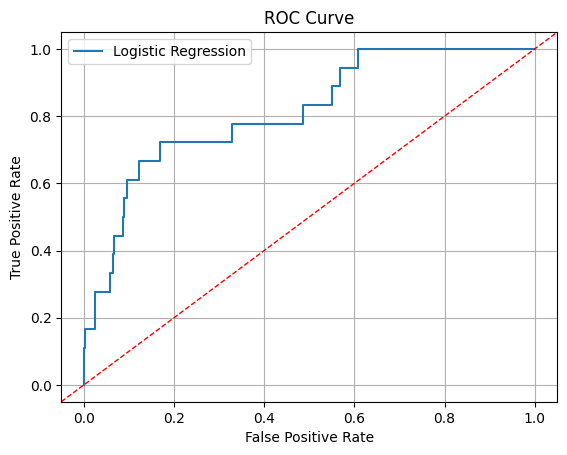

<Figure size 640x480 with 0 Axes>

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.show()
plt.clf()

Elastic Net Logistic Regression (Grid Search)

In [8]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit

param_grid = {
    'C': 1 / np.logspace(-4, 0, 101),  # Inverse of regularization
    'l1_ratio': np.linspace(0, 1, 11)
}

# Using `saga` solver for elastic net logistic regression
lr_model = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000)

test_fold = np.array([-1]*len(X_train) + [0]*len(X_val))

split = PredefinedSplit(test_fold)

lr_grid = GridSearchCV(
    lr_model,
    param_grid = {
        'C': 1 / np.logspace(-4, 0, 5),
        'l1_ratio': np.linspace(0, 1, 5)
    },
    scoring = 'roc_auc', cv = split, verbose = 2, n_jobs = cores
)

lr_grid.fit(X_train_val, y_train_val)
print("Best parameters:", lr_grid.best_params_)

Fitting 1 folds for each of 25 candidates, totalling 25 fits
Best parameters: {'C': 1.0, 'l1_ratio': 0.0}


ROC Curve

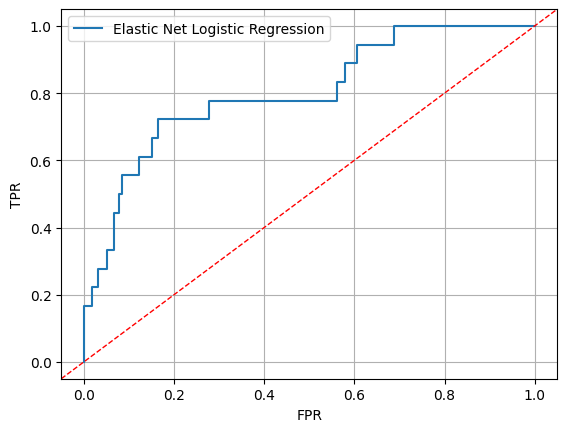

<Figure size 640x480 with 0 Axes>

In [9]:
lr_best = lr_grid.best_estimator_
y_test_prob = lr_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Elastic Net Logistic Regression')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Random Forest

In [10]:
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(n_estimators=100, n_jobs=cores)

rf_grid = {
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

rf_search = RandomizedSearchCV(
    rf_model, rf_grid, n_iter=15, cv=split, scoring='roc_auc', n_jobs=cores
)
rf_search.fit(X_train_val, y_train_val)
print("Best RF parameters:", rf_search.best_params_)

Best RF parameters: {'min_samples_leaf': 1, 'max_features': None}


ROC

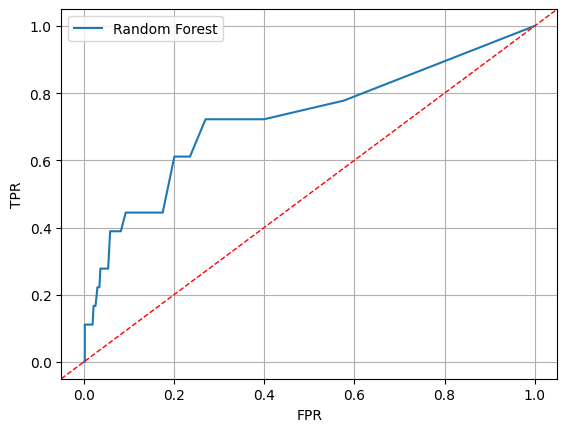

<Figure size 640x480 with 0 Axes>

In [11]:
rf_best = rf_search.best_estimator_
y_test_prob = rf_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Gradient Boosted Trees (XGBoost)

In [13]:
gb_model = XGBClassifier(n_estimators=250, n_jobs=cores, eval_metric='logloss')

gb_grid = {
    'min_child_weight': [1, 5, 10],
    'gamma': [0, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

gb_search = RandomizedSearchCV(
    gb_model, gb_grid, n_iter=25, scoring='roc_auc', n_jobs=cores, cv=split
)
gb_search.fit(X_train_val, y_train_val)
print("Best GB parameters:", gb_search.best_params_)

Best GB parameters: {'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1}


ROC

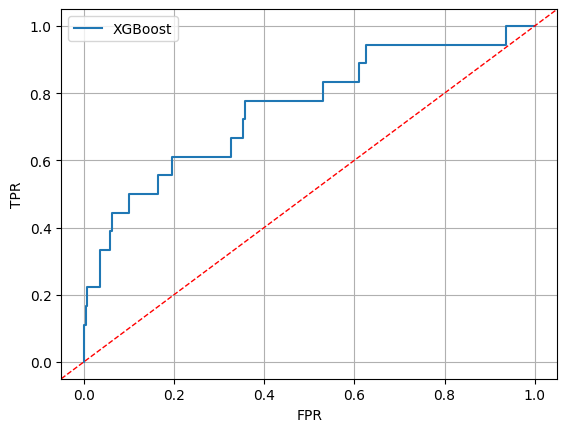

<Figure size 640x480 with 0 Axes>

In [14]:
xgb_best = gb_search.best_estimator_
y_test_prob = xgb_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.plot(fpr, tpr, label='XGBoost')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle = '--', color='r')
plt.grid()
plt.show()
plt.clf()

Multi-layer Perceptron (MLP)

ROC

Final Evaluation on Test Set

In [17]:
models = {
    'Logistic Regression': blr_model,
    'Elastic Net': lr_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"{name}")
    print("Precision:", precision_score(y_test, y_pred, zero_division = 0))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print("PR AUC:", average_precision_score(y_test, y_prob))
    print()

Logistic Regression
Precision: 1.0
ROC AUC: 0.8142548596112311
PR AUC: 0.2849120308564295

Elastic Net
Precision: 1.0
ROC AUC: 0.802975761939045
PR AUC: 0.29725129716026477

Random Forest
Precision: 0.5
ROC AUC: 0.7222822174226062
PR AUC: 0.17337677783697053

XGBoost
Precision: 0.0
ROC AUC: 0.7552195824334054
PR AUC: 0.2722946741244405



(utestet kode herunder)

Feature Importance (when applicable)

**DEVNOTE: The following code needs NumPy 1.23.5 in the 'shap_values' function. The implementaion relies on a earlier version of numpy as the int statement changes in newer versions. See: https://stackoverflow.com/questions/74946845/attributeerror-module-numpy-has-no-attribute-int** 

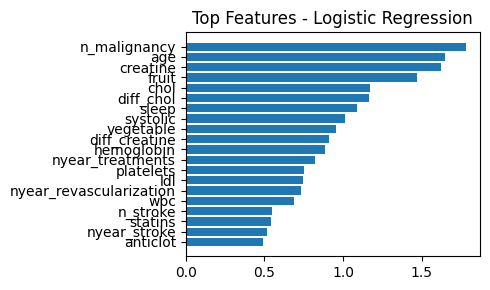

<Figure size 640x480 with 0 Axes>

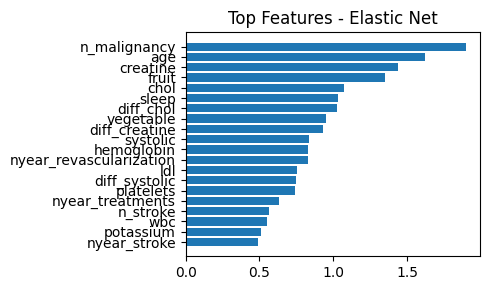

<Figure size 640x480 with 0 Axes>

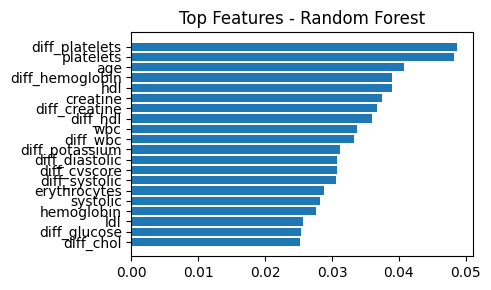

<Figure size 640x480 with 0 Axes>

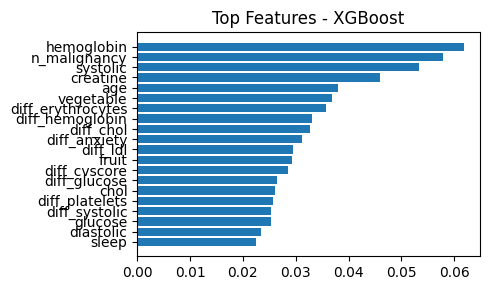

<Figure size 640x480 with 0 Axes>

In [18]:
from sklearn.inspection import permutation_importance
from itertools import chain
import shap
from sklearn.datasets import load_iris

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif name in {'Elastic Net', 'Logistic Regression'}:
        importances = np.array(list(chain.from_iterable([abs(number) for number in model.coef_])))
    else:
        # Use KernelExplainer (model-agnostic)
        explainer = shap.KernelExplainer(model.predict_proba, X_train[:50], rng = 42)
        shap_values = explainer.shap_values(X_test[:10], rng = 42)  # smaller subset for speed
        shap_array = np.array(shap_values[1])
        importances = np.abs(shap_array).mean(axis=0)

    top_idx = np.argsort(importances)[::-1][:20]
    plt.figure(figsize=(5,3))
    plt.barh(np.array(X.columns)[top_idx], importances[top_idx])
    plt.title(f"Top Features - {name}")
    plt.tight_layout()
    plt.gca().invert_yaxis()
    plt.show()
    plt.clf()

Calibration model.

C:\Users\jakob\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


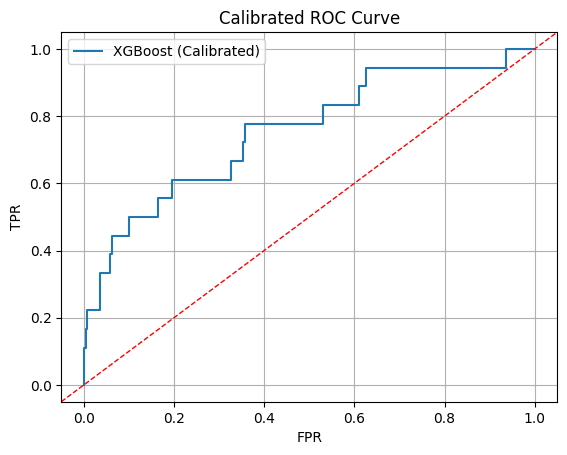

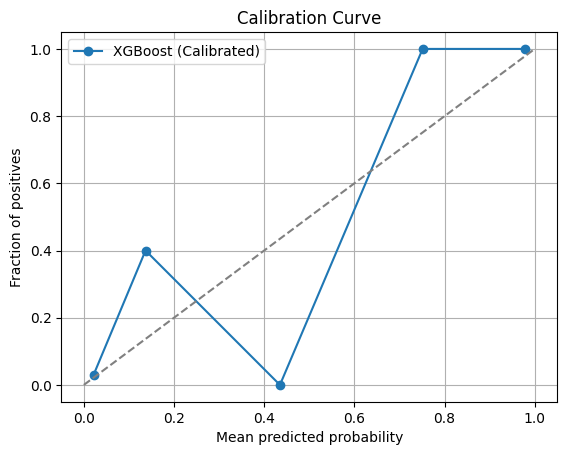

<Figure size 640x480 with 0 Axes>

In [19]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Fit calibrated model using the separate calibration set
xgb_calibrated = CalibratedClassifierCV(xgb_best, method='sigmoid', cv='prefit')
xgb_calibrated.fit(X_cal, y_cal)

# Evaluate calibrated model on the test set
y_test_prob_calibrated = xgb_calibrated.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob_calibrated)

plt.plot(fpr, tpr, label='XGBoost (Calibrated)')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.axline((0, 0), (1, 1), linewidth=1, linestyle='--', color='r')
plt.grid()
plt.title("Calibrated ROC Curve")
plt.show()
plt.clf()

# Calibration curve (Reliability diagram)
prob_true, prob_pred = calibration_curve(y_test, y_test_prob_calibrated, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='XGBoost (Calibrated)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid()
plt.show()
plt.clf()

Save model for workshop 3.

In [20]:
import joblib

# Save model
joblib.dump(blr_model, "trained_model.joblib")

['trained_model.joblib']